In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load the IBM Telco Churn dataset directly
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn value counts:")
print(df['Churn'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
# TotalCharges has some hidden spaces — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls that created
print("Nulls after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill the small number of nulls with 0 (new customers with no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID — it's just an ID, not useful for analysis
df = df.drop('customerID', axis=1)

# Convert Churn to 1/0 so we can do maths on it
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Quick summary of the key numeric columns
print("\nKey stats:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].describe().round(2))

print(f"\nOverall churn rate: {df['Churn'].mean()*100:.1f}%")

Nulls after conversion:
TotalCharges    11
dtype: int64

Key stats:
        tenure  MonthlyCharges  TotalCharges    Churn
count  7043.00         7043.00       7043.00  7043.00
mean     32.37           64.76       2279.73     0.27
std      24.56           30.09       2266.79     0.44
min       0.00           18.25          0.00     0.00
25%       9.00           35.50        398.55     0.00
50%      29.00           70.35       1394.55     0.00
75%      55.00           89.85       3786.60     1.00
max      72.00          118.75       8684.80     1.00

Overall churn rate: 26.5%


In [ ]:
# --- Driver 1: Contract type ---
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print("Churn rate by contract type:")
print(contract_churn.round(1).to_string())

# --- Driver 2: Tenure groups ---
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'])
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
print("\nChurn rate by tenure:")
print(tenure_churn.round(1).to_string())

# --- Driver 3: Internet service ---
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
print("\nChurn rate by internet service:")
print(internet_churn.round(1).to_string())

# --- Driver 4: Monthly charges buckets ---
df['charge_group'] = pd.cut(df['MonthlyCharges'],
    bins=[0, 35, 65, 90, 120],
    labels=['$0-35', '$36-65', '$66-90', '$91-120'])
charge_churn = df.groupby('charge_group', observed=True)['Churn'].mean() * 100
print("\nChurn rate by monthly charge:")
print(charge_churn.round(1).to_string())

# --- Driver 5: Senior citizens ---
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100
print("\nChurn rate: non-senior vs senior:")
print(senior_churn.round(1).to_string())

Churn rate by contract type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

Churn rate by tenure:
tenure_group
0-12 months     47.7
13-24 months    28.7
25-48 months    20.4
49-72 months     9.5

Churn rate by internet service:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4

Churn rate by monthly charge:
charge_group
$0-35      10.9
$36-65     23.1
$66-90     36.3
$91-120    32.8

Churn rate: non-senior vs senior:
SeniorCitizen
0    23.6
1    41.7


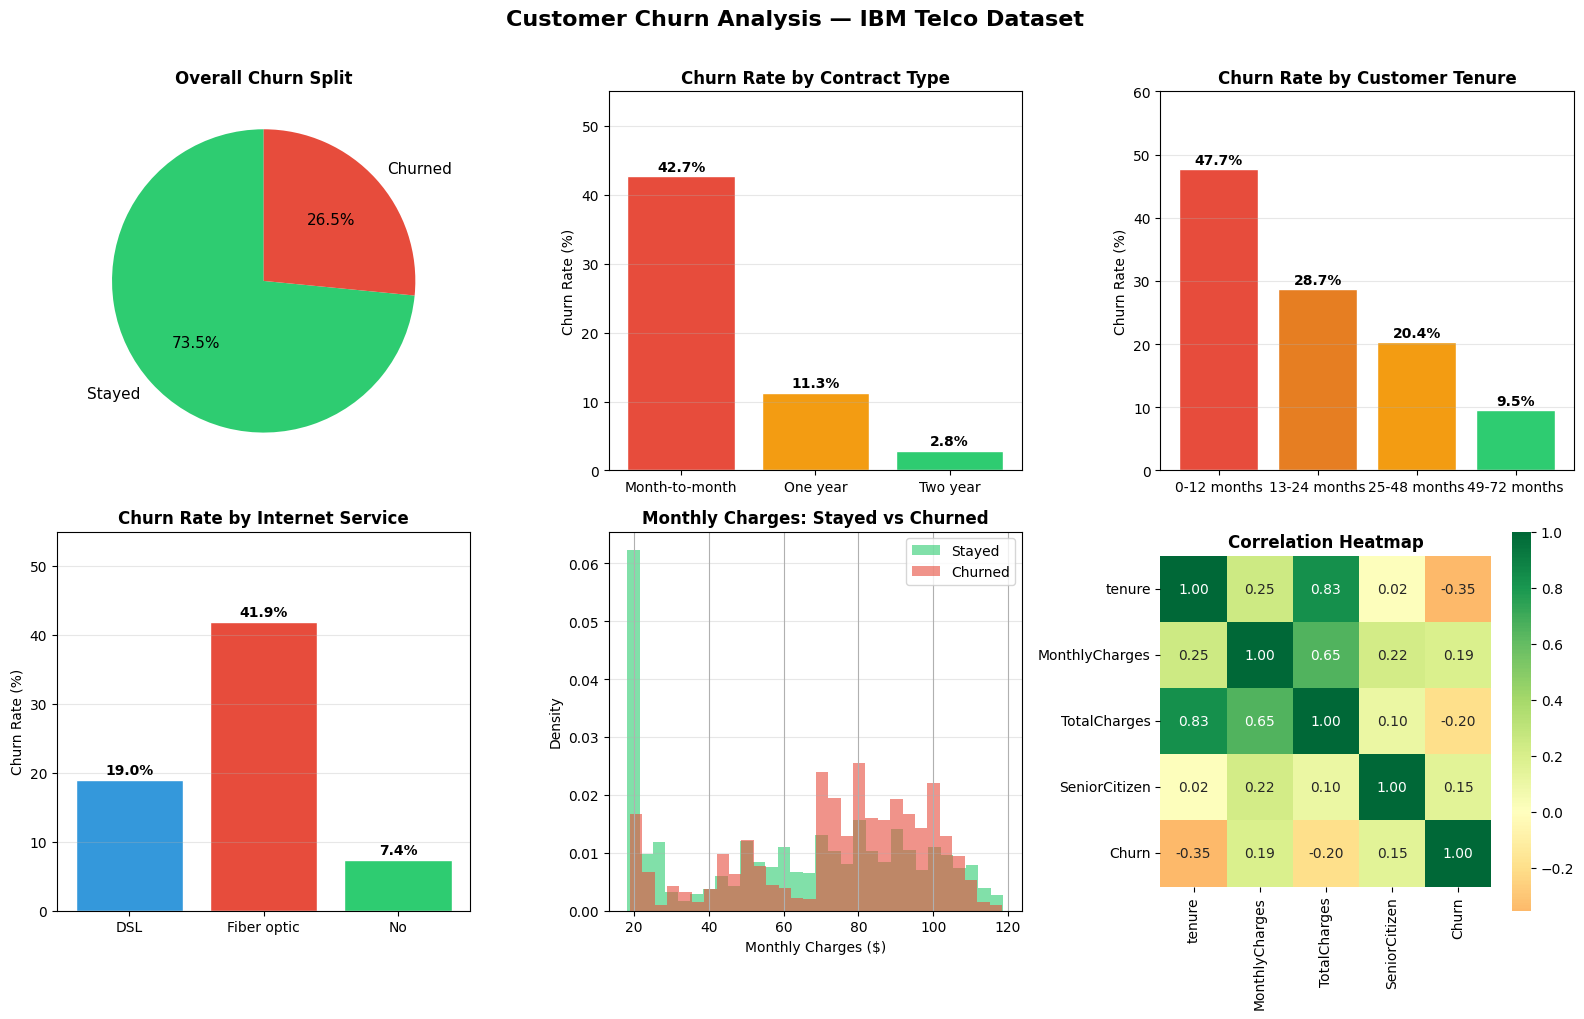

Chart saved as churn_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Churn Analysis — IBM Telco Dataset',
             fontsize=16, fontweight='bold', y=1.01)

colors_main = ['#2ecc71', '#e74c3c']

# --- Chart 1: Overall churn split (pie) ---
ax1 = axes[0, 0]
sizes = df['Churn'].value_counts()
ax1.pie(sizes, labels=['Stayed', 'Churned'],
        colors=colors_main, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11})
ax1.set_title('Overall Churn Split', fontweight='bold')

# --- Chart 2: Churn by contract type ---
ax2 = axes[0, 1]
bars = ax2.bar(contract_churn.index, contract_churn.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
ax2.set_title('Churn Rate by Contract Type', fontweight='bold')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_ylim(0, 55)
for bar, val in zip(bars, contract_churn.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# --- Chart 3: Churn by tenure group ---
ax3 = axes[0, 2]
bars3 = ax3.bar(tenure_churn.index, tenure_churn.values,
                color=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71'],
                edgecolor='white')
ax3.set_title('Churn Rate by Customer Tenure', fontweight='bold')
ax3.set_ylabel('Churn Rate (%)')
ax3.set_ylim(0, 60)
for bar, val in zip(bars3, tenure_churn.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# --- Chart 4: Churn by internet service ---
ax4 = axes[1, 0]
bars4 = ax4.bar(internet_churn.index, internet_churn.values,
                color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white')
ax4.set_title('Churn Rate by Internet Service', fontweight='bold')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_ylim(0, 55)
for bar, val in zip(bars4, internet_churn.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# --- Chart 5: Monthly charges distribution by churn ---
ax5 = axes[1, 1]
df[df['Churn'] == 0]['MonthlyCharges'].hist(ax=ax5, bins=30, alpha=0.6,
    color='#2ecc71', label='Stayed', density=True)
df[df['Churn'] == 1]['MonthlyCharges'].hist(ax=ax5, bins=30, alpha=0.6,
    color='#e74c3c', label='Churned', density=True)
ax5.set_title('Monthly Charges: Stayed vs Churned', fontweight='bold')
ax5.set_xlabel('Monthly Charges ($)')
ax5.set_ylabel('Density')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# --- Chart 6: Correlation heatmap ---
ax6 = axes[1, 2]
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax6, square=True,
            annot_kws={'size': 10})
ax6.set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as churn_analysis.png")

In [ ]:
# --- Prepare features for the model ---
# Select the most impactful columns we analysed
features = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
               'Contract', 'InternetService', 'PaperlessBilling']]

# Convert text columns to numbers (one-hot encoding)
features = pd.get_dummies(features, columns=['Contract', 'InternetService',
                                              'PaperlessBilling'], drop_first=True)
target = df['Churn']

print("Feature columns:", features.columns.tolist())
print("Total features:", len(features.columns))

# --- Split into training and test sets (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42)

print(f"\nTraining rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

# --- Train logistic regression model ---
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# --- Evaluate ---
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100

print(f"\nModel accuracy: {accuracy:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

Feature columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaperlessBilling_Yes']
Total features: 9

Training rows: 5634
Testing rows:  1409

Model accuracy: 81.1%

Detailed report:
              precision    recall  f1-score   support

      Stayed       0.85      0.91      0.88      1036
     Churned       0.68      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



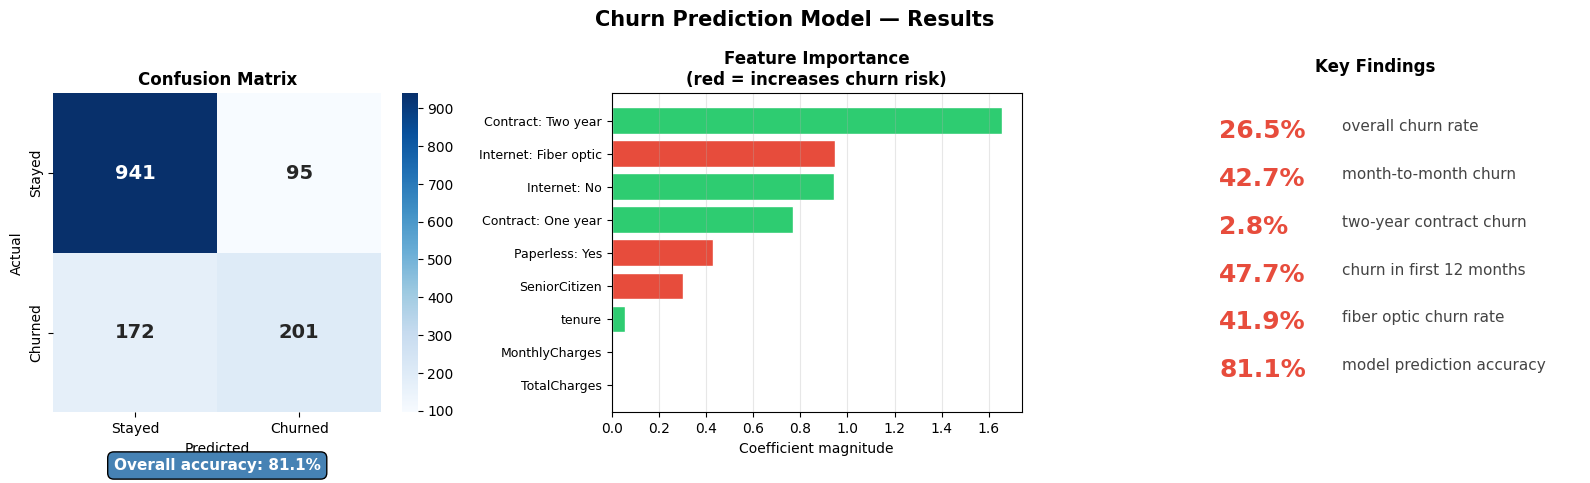

Saved: churn_model_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Churn Prediction Model — Results', fontsize=15, fontweight='bold')

# --- Chart 1: Confusion matrix ---
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# Add accuracy badge
ax1.text(0.5, -0.18, f'Overall accuracy: {accuracy:.1f}%',
         transform=ax1.transAxes, ha='center', fontsize=11,
         color='white', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='steelblue'))

# --- Chart 2: Feature importance ---
ax2 = axes[1]
importance = pd.Series(model.coef_[0], index=features.columns)
importance_sorted = importance.abs().sort_values(ascending=True)

colors = ['#e74c3c' if importance[col] > 0 else '#2ecc71'
          for col in importance_sorted.index]
bars = ax2.barh(range(len(importance_sorted)), importance_sorted.values,
                color=colors, edgecolor='white')

ax2.set_yticks(range(len(importance_sorted)))
ax2.set_yticklabels([col.replace('_', ' ').replace('Contract ', 'Contract: ')
                     .replace('InternetService ', 'Internet: ')
                     .replace('PaperlessBilling ', 'Paperless: ')
                     for col in importance_sorted.index], fontsize=9)
ax2.set_title('Feature Importance\n(red = increases churn risk)', fontweight='bold')
ax2.set_xlabel('Coefficient magnitude')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(x=0, color='gray', linewidth=0.5)

# --- Chart 3: Top 5 insights summary ---
ax3 = axes[2]
ax3.axis('off')
insights = [
    ("26.5%",  "overall churn rate"),
    ("42.7%",  "month-to-month churn"),
    ("2.8%",   "two-year contract churn"),
    ("47.7%",  "churn in first 12 months"),
    ("41.9%",  "fiber optic churn rate"),
    ("81.1%",  "model prediction accuracy"),
]
ax3.set_title('Key Findings', fontweight='bold', pad=15)
y_pos = 0.92
for val, label in insights:
    ax3.text(0.12, y_pos, val, transform=ax3.transAxes,
             fontsize=18, fontweight='bold', color='#e74c3c', va='top')
    ax3.text(0.42, y_pos, label, transform=ax3.transAxes,
             fontsize=11, color='#444', va='top')
    y_pos -= 0.15

plt.tight_layout()
plt.savefig('churn_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: churn_model_results.png")

# Download both charts
from google.colab import files
files.download('churn_analysis.png')
files.download('churn_model_results.png')

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         CUSTOMER CHURN ANALYSIS — PROJECT SUMMARY            ║
╚══════════════════════════════════════════════════════════════╝

WHAT I BUILT:
  End-to-end churn analysis pipeline — from raw customer data
  to visualised insights to a working prediction model.

TOOLS USED:
  • Python (Google Colab)
  • Pandas — data cleaning and feature engineering
  • Matplotlib + Seaborn — 6-panel analysis dashboard
  • Scikit-learn — logistic regression model

DATA:
  • IBM Telco dataset — 7,043 real customers, 21 features
  • 26.5% overall churn rate

KEY INSIGHTS DISCOVERED:
  • Month-to-month contracts churn at 42.7% vs 2.8% on 2-year
  • Nearly half of customers leave in their first 12 months
  • Fiber optic customers churn at 41.9% despite premium pricing
  • Senior citizens churn at 41.7% vs 23.6% non-seniors
  • Tenure is the strongest protective factor (-0.35 correlation)

MODEL RESULTS:
  • Algorithm: Logistic Regression
  • Accuracy: 81.1%
  • Correctly identifies 91% of customers who will stay
  • Correctly flags 54% of customers who will churn

FILES SAVED:
  • churn_analysis.png       — 6-panel insight dashboard
  • churn_model_results.png  — confusion matrix + feature importance

╔══════════════════════════════════════════════════════════════╗
║                     PROJECT COMPLETE                          ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         CUSTOMER CHURN ANALYSIS — PROJECT SUMMARY            ║
╚══════════════════════════════════════════════════════════════╝

WHAT I BUILT:
  End-to-end churn analysis pipeline — from raw customer data
  to visualised insights to a working prediction model.

TOOLS USED:
  • Python (Google Colab)
  • Pandas — data cleaning and feature engineering
  • Matplotlib + Seaborn — 6-panel analysis dashboard
  • Scikit-learn — logistic regression model

DATA:
  • IBM Telco dataset — 7,043 real customers, 21 features
  • 26.5% overall churn rate

KEY INSIGHTS DISCOVERED:
  • Month-to-month contracts churn at 42.7% vs 2.8% on 2-year
  • Nearly half of customers leave in their first 12 months
  • Fiber optic customers churn at 41.9% despite premium pricing
  • Senior citizens churn at 41.7% vs 23.6% non-seniors
  • Tenure is the strongest protective factor (-0.35 correlation)

MODEL RESULTS:
  • Algorithm: Logistic Regression
  